# Generation, oversampling, and traceability

Generate synthetic rows and inspect their trace records.

In [1]:
import sys
from pathlib import Path

from IPython.display import display

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src" / "mimic").exists() else Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
if NOTEBOOK_DIR.exists() and str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from mimic import MIMIC
from mimic_notebook_utils import (
    append_generated_rows,
    cell_sampling_trace,
    class_balance,
    generated_embedding_trace,
    identity_generation_plot,
    make_two_spiral_frame,
    plot_oversampling,
)

MAJORITY_SAMPLES = 250
MINORITY_SAMPLES = MAJORITY_SAMPLES // 2

df = make_two_spiral_frame(
    majority_samples=MAJORITY_SAMPLES,
    minority_samples=MINORITY_SAMPLES,
    random_state=2,
)

display(class_balance(df).style.set_caption("Original class balance"))
display(df.head(8).style.set_caption("Original two-spiral training rows"))


,count
label,
majority,250
minority,125


,x,y,label,id
0,0.247798,0.090811,majority,0
1,0.168761,0.206043,majority,1
2,0.186642,0.008847,majority,2
3,-0.053813,0.116717,majority,3
4,0.456219,0.104372,majority,4
5,0.376696,0.070445,majority,5
6,0.197465,0.467894,majority,6
7,0.324404,0.371906,majority,7


In [2]:
mimic = MIMIC(
    columns={"ignore": ["id"],"regression": ["x", "y"],"classification": ["label"],},
    mode="joint", # modes: "identity", "direct", "factorised", "joint"
    capacity=0.25,
    random_state=2,
    verbose=True,
)
mimic.fit(df)
synthetic, trace = mimic.sample(12, return_trace=True)

display(generated_embedding_trace(synthetic, trace).head(8).style.set_caption("Generated rows with embedding trace"))
display(cell_sampling_trace(trace).head(12).style.set_caption("Per-cell stochastic sampling trace"))


MIMIC init hyperparameters:
  capacity: 0.25
  columns:
    ignore:
      - id
    regression:
      - x
      - y
    classification:
      - label
  decoder: NeuralConditionalSampler
  encoder: ResNetEncoder
  generation_decode_mode: joint
  level: None
  mode: joint
  n_bootstrap: None
  n_jobs: None
  policy: GenerationPolicy
  random_state: 2
  verbose: True
  capacity_parameters:
    embedding_dim: 33
    hidden_dim: 38
    n_layers: 3
    max_epochs: 82
    patience: 9
    batch_size: 88
    n_components: 3
    n_bootstrap: 2
    dropout: 0.05
    learning_rate: 0.0016870239755710477
    weight_decay: 5.623413251903493e-06
MIMIC resolved fit configuration:
  mode_: joint
  level_: 3
  capacity_: 0.25
  capacity_parameters_:
    embedding_dim: 33
    hidden_dim: 38
    n_layers: 3
    max_epochs: 82
    patience: 9
    batch_size: 88
    n_components: 3
    n_bootstrap: 2
    dropout: 0.05
    learning_rate: 0.0016870239755710477
    weight_decay: 5.623413251903493e-06
  n_bootst

,x,y,label,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,decoder
0,1.578750,-1.751946,minority,314,316,315,0.399246,mutual,NeuralConditionalSampler
1,-0.724154,-2.097761,minority,305,303,304,0.550050,mutual,NeuralConditionalSampler
2,-0.994849,-1.943621,minority,304,306,304,0.343951,mutual,NeuralConditionalSampler
3,0.091004,0.478822,majority,20,15,17,0.578717,mutual,NeuralConditionalSampler
4,1.367819,1.543562,majority,114,111,113,0.325031,mutual,NeuralConditionalSampler
5,-2.350047,-1.136864,majority,162,157,156,0.461392,mutual,NeuralConditionalSampler
6,0.816840,-1.425600,majority,82,85,82,0.733718,mutual,NeuralConditionalSampler
7,-0.231819,-0.263323,minority,256,258,255,0.343626,mutual,NeuralConditionalSampler


In [3]:
minority_needed = df["label"].value_counts()["majority"] - df["label"].value_counts()["minority"]
minority_synthetic, minority_trace = mimic.sample(
    minority_needed,
    condition={"label": "minority"},
    return_trace=True,
)
balanced = append_generated_rows(df, minority_synthetic)

display(class_balance(balanced).style.set_caption("Class balance after minority-conditioned displacement oversampling"))
display(generated_embedding_trace(minority_synthetic, minority_trace, include_condition=True).head(8).style.set_caption("Synthetic minority rows with embedding trace"))
display(cell_sampling_trace(minority_trace).head(12).style.set_caption("Minority per-cell stochastic sampling trace"))


,count
label,
majority,250
minority,250


,x,y,label,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,condition,decoder
0,-2.960561,-1.894147,minority,354,352,354,0.399246,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
1,-3.131086,-1.043631,minority,351,354,353,0.550050,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
2,-3.212086,-1.067124,minority,351,350,349,0.343951,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
3,-0.234508,-0.245805,minority,256,257,255,0.578717,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
4,-1.080728,1.071359,minority,288,291,292,0.325031,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
5,-0.991860,-1.968121,minority,304,306,305,0.461392,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
6,0.889656,1.109251,minority,277,278,281,0.733718,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
7,0.690371,2.847194,minority,335,337,338,0.343626,mutual,"{""label"": ""minority""}",NeuralConditionalSampler


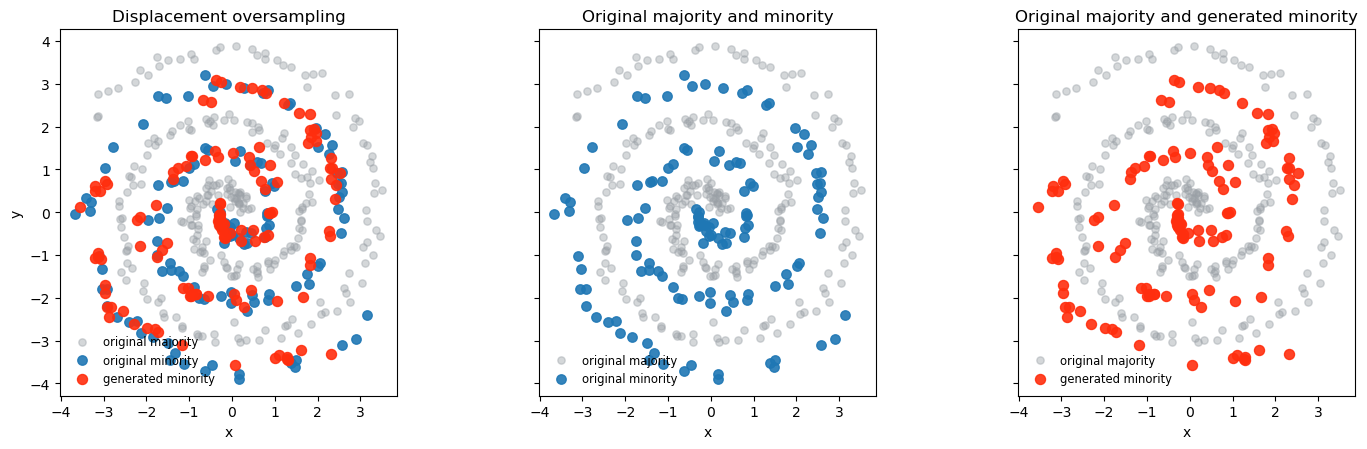

In [4]:
fig, ax = plot_oversampling(df, minority_synthetic)


## Identity-space configurable baseline

Set the full MIMIC estimator here with `mode="identity"` to generate in the preprocessed original feature space.

,method,neighbour_mode,n_neighbors,lambda_range,n_generated,trace_rows,x_min,x_max,y_min,y_max
0,displacement,mutual,5,"(0.25, 0.75)",125,125,-3.749870,3.267367,-3.711481,3.178076


,x,y,label
0,-2.973025,-1.640637,minority
1,-3.165820,-1.018132,minority
2,-3.023007,-1.390681,minority
3,-0.165112,-0.213611,minority
4,-0.874174,1.137370,minority
5,-1.004109,-2.012601,minority
6,1.008741,0.232532,minority
7,0.690552,2.984424,minority


,trace_type,sample_index,method,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,restriction,condition,decoder,generation_decode_mode,resolved_generation_decode_mode,random_state
0,embedding,0,displacement,354,355,353,0.399246,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,auto,direct,2
1,embedding,1,displacement,351,354,353,0.550050,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,auto,direct,2
2,embedding,2,displacement,351,350,351,0.343951,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,auto,direct,2
3,embedding,3,displacement,256,257,258,0.578717,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,auto,direct,2
4,embedding,4,displacement,288,291,288,0.325031,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,auto,direct,2
5,embedding,5,displacement,304,306,304,0.461392,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,auto,direct,2
6,embedding,6,displacement,277,278,274,0.733718,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,auto,direct,2
7,embedding,7,displacement,335,334,335,0.343626,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,auto,direct,2


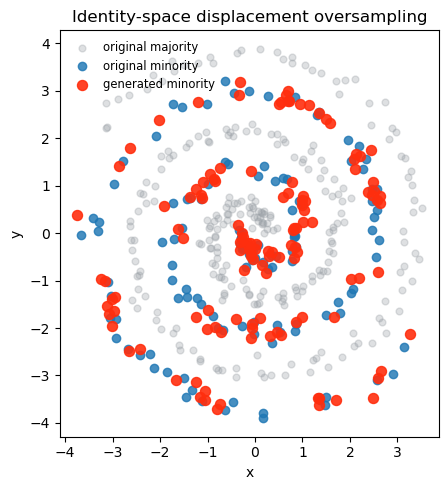

In [5]:
identity_mimic = MIMIC(
    columns={
        "ignore": ["id"],
        "regression": ["x", "y"],
        "classification": ["label"],
    },
    # modes: "identity", "direct", "factorised", "joint"
    mode="identity",
    capacity=0.0,
    random_state=2,
)

identity_summary, identity_synthetic, identity_trace, identity_fig, identity_ax = identity_generation_plot(
    identity_mimic,
    df,
    n_samples=minority_needed,
    condition={"label": "minority"},
    title="Identity-space displacement oversampling",
)

display(identity_summary.style.set_caption("Identity-space generation summary"))
display(identity_synthetic.head(8).style.set_caption("Identity-space synthetic minority rows"))
display(identity_trace.head(8).style.set_caption("Identity-space generation trace"))